# 🏦 Loan Approval Model — Classification & Cost-Sensitive Decision Making

**Session 4 | Industrial Use Case 1 | DSA & ML for Business**

---

### Business Context
- Global consumer lending: **$4.2 Trillion** outstanding — 2-5% default rate
- **1% improvement** in prediction = **billions** in saved write-offs
- Regulatory requirement: models must be **explainable**
- Challenge: **class imbalance** — only 5-8% of loans actually default
- **False Negative cost >> False Positive cost** — missing a default is catastrophic

### What You'll Learn
1. Handle **imbalanced classification** with class weights
2. Train **Decision Tree** (explainable) and **Random Forest** (accurate)
3. Evaluate with **precision, recall, F1, ROC-AUC**
4. Apply **business cost matrix** to select the optimal model
5. **ROC threshold optimization** for minimum total business cost

## Step 1: Import Libraries & Load Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

### Load Dataset & Inspect

In [5]:
df = pd.read_csv("../datasets/loan_approval.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (4000, 7)
Columns: ['credit_score', 'income', 'loan_amount', 'employment_years', 'debt_to_income', 'previous_defaults', 'default']


,credit_score,income,loan_amount,employment_years,debt_to_income,previous_defaults,default
0,843,233565.94,336174.22,14.97,0.13,0,0
1,538,234053.74,596912.74,33.57,0.69,0,1
2,690,48015.64,55386.43,13.57,0.49,0,0
3,334,137993.38,384256.37,24.84,0.22,0,0
4,401,21651.80,11128.45,18.49,0.50,0,0


### Check Class Imbalance

In loan data, most borrowers **don't default** — typically only 5-8% do. This creates **class imbalance**, which is critical to understand before training.

**Why it matters:** If 95% of loans are "no default", a model that always predicts "no default" gets 95% accuracy but catches **zero** actual defaults — completely useless for a bank!

In [6]:
print("Class distribution:")
print(df['default'].value_counts())
print(f"\nDefault rate: {df['default'].mean():.2%}")
print(f"\n⚠️ This is imbalanced — {1 - df['default'].mean():.0%} are 'no default'")
df.describe().round(2)

Class distribution:
default
0    2796
1    1204
Name: count, dtype: int64

Default rate: 30.10%

⚠️ This is imbalanced — 70% are 'no default'


,credit_score,income,loan_amount,employment_years,debt_to_income,previous_defaults,default
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,571.20,135592.13,208610.66,17.35,0.42,0.24,0.30
std,159.45,66953.24,164833.44,10.11,0.22,0.72,0.46
min,300.00,20070.88,5033.94,0.01,0.05,0.00,0.00
25%,436.00,78102.79,74645.41,8.61,0.24,0.00,0.00
50%,563.00,135546.59,163139.06,17.22,0.43,0.00,0.00
75%,713.25,195130.25,303063.73,26.10,0.61,0.00,1.00
max,850.00,249997.95,741181.50,35.00,0.80,3.00,1.00


## Step 2: EDA — Feature Analysis & Class Imbalance

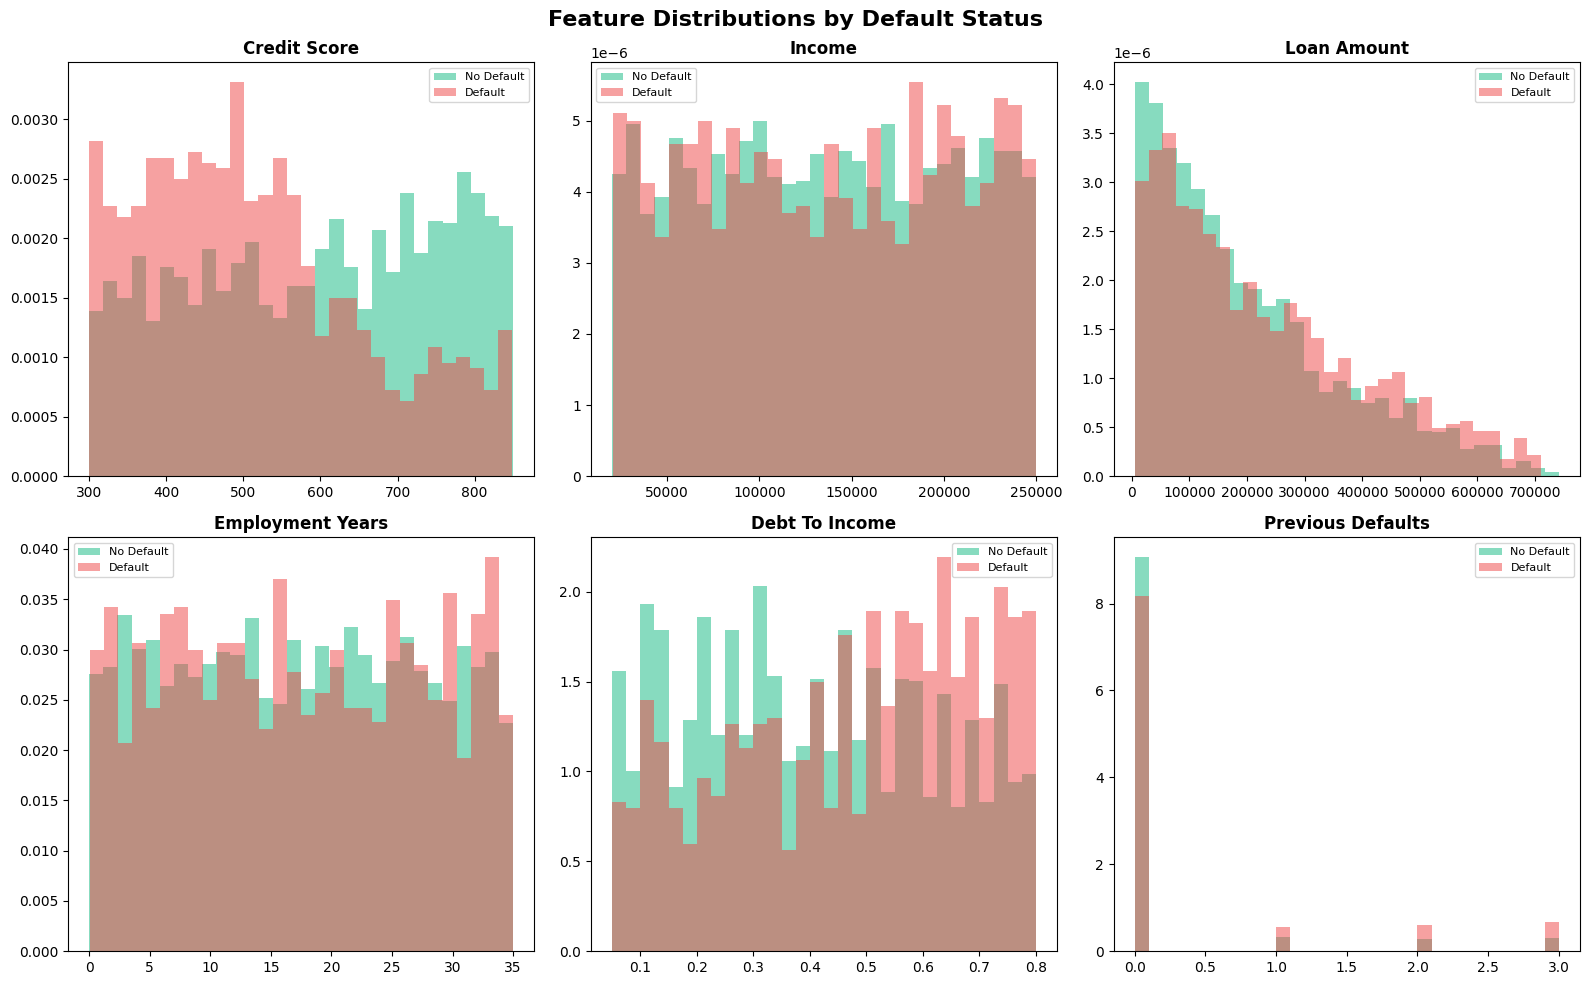

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['credit_score', 'income', 'loan_amount', 'employment_years', 'debt_to_income', 'previous_defaults']
for ax, feat in zip(axes.flat, features):
    for label, color in [(0, '#10B981'), (1, '#EF4444')]:
        ax.hist(df[df['default'] == label][feat], bins=30, alpha=0.5,
                label=f'{"Default" if label else "No Default"}', color=color, density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Default Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3: Train-Test Split & Feature Scaling

### Why do we split data into Train & Test?

We hold out 25% of data as a **test set** the model has never seen.

| Scenario | What Happens |
|----------|-------------|
| ✅ **With split** | Model trains on 75%, we evaluate on unseen 25% — measures real-world performance |
| ❌ **Without split** | Model memorizes all data, reports amazing accuracy, but **fails on new loans** |

Think of it like a student who studies from a textbook (training) and then takes an **unseen exam** (test). If the exam has the same questions as the textbook, we can't tell if they actually learned.

### Why `stratify=y`?

Since only ~5-8% of loans default, a random split might accidentally put very few defaults in the test set. `stratify=y` ensures both sets have the **same default rate**.

| `stratify=y` | Target column | Ensures train & test sets have the **same class ratio** (e.g., both ~7% default). Critical for imbalanced data |

### Parameters in `train_test_split()`| `random_state=42` | Any integer | Makes the split **reproducible**. Without it, you get a different split every run and results change each time. 42 is just a convention (hitchhiker's guide!) — any number works |

| `test_size=0.25` | 25% | Fraction of data held out for testing. 0.25 = 75% train, 25% test. Common choices: 0.2–0.3 |

| Parameter | Value | What It Does ||-----------|-------|-------------|

In [8]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples | Default rate: {y_train.mean():.2%}")
print(f"Test set:     {X_test.shape[0]} samples | Default rate: {y_test.mean():.2%}")
print(f"\n✅ Both sets have similar default rates — stratification worked!")

Training set: 3000 samples | Default rate: 30.10%
Test set:     1000 samples | Default rate: 30.10%

✅ Both sets have similar default rates — stratification worked!


### Why do we need Scaling?

SGD Classifier uses **gradient descent**, which is sensitive to feature scales. If `income` ranges 20,000–200,000 but `debt_to_income` ranges 0–1, the gradient will oscillate wildly.

| Model | Needs Scaling? | Why |
|-------|:-:|------|
| Decision Tree | ❌ No | Splits on single features, scale doesn't matter |
| Random Forest | ❌ No | Ensemble of decision trees |
| SGD Classifier | ✅ Yes | Gradient descent converges faster on scaled features |

**What happens if we don't scale for SGD?**
- Training may **not converge** (fails to find a good solution)
- Or converges **very slowly** — needs 100x more iterations
- Features with large values dominate the model

> **Note:** We only scale for SGD. Tree-based models don't need it — they split on individual feature thresholds.

⚠️ **Why not `fit_transform` on test data too?** Because in the real world, the model won't know future data's statistics. Using training stats on test data simulates real deployment.

### What does `StandardScaler()` do?

`transform(X_test)` — uses the **same** mean & std from training to transform test data.
`fit_transform(X_train)` — learns mean & std from training data, then transforms it.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show the range difference before and after scaling
print("=== Feature Ranges BEFORE Scaling ===")
for col in X_train.columns[:4]:
    print(f"  {col:25s} → min: {X_train[col].min():10.2f}  max: {X_train[col].max():10.2f}")

print("\n=== Feature Ranges AFTER Scaling (mean≈0, std≈1) ===")
for i, col in enumerate(X_train.columns[:4]):
    print(f"  {col:25s} → min: {X_train_scaled[:, i].min():10.2f}  max: {X_train_scaled[:, i].max():10.2f}")

print("\n✅ All features now on similar scale — SGD will converge properly")

=== Feature Ranges BEFORE Scaling ===
  credit_score              → min:     300.00  max:     850.00
  income                    → min:   20070.88  max:  249989.43
  loan_amount               → min:    5033.94  max:  740737.27
  employment_years          → min:       0.01  max:      35.00

=== Feature Ranges AFTER Scaling (mean≈0, std≈1) ===
  credit_score              → min:      -1.69  max:       1.78
  income                    → min:      -1.73  max:       1.71
  loan_amount               → min:      -1.24  max:       3.23
  employment_years          → min:      -1.69  max:       1.75

✅ All features now on similar scale — SGD will converge properly


## Step 4: Train Models — Decision Tree, Random Forest, SGD

### Why `class_weight='balanced'`?

Remember, only ~5-8% of loans default. Without handling this imbalance:

| Scenario | What Happens |
|----------|-------------|
| ❌ **Without balanced weights** | Model predicts "no default" for everyone → 95% accuracy but **catches 0% of actual defaults** |
| ✅ **With `class_weight='balanced'`** | Model penalizes missing a default more heavily → learns to detect the minority class |

**How it works internally:** The algorithm computes a weight for each class using this formula:

$$w_j = \frac{n}{k \times n_j}$$

Where:
- $n$ = total number of samples
- $k$ = number of classes (2 for loan default: yes/no)
- $n_j$ = number of samples in class $j$

**Concrete Example:** If we have 900 "no default" and 100 "default" loans:
- Weight for "no default" = 1000 / (2 × 900) = **0.56** (downweighted — already well-represented)
- Weight for "default" = 1000 / (2 × 100) = **5.0** (upweighted — rare but important)

This means misclassifying a default costs the model **~9× more** than misclassifying a non-default during training, forcing it to pay attention to the minority class.

### Parameters in `DecisionTreeClassifier()`

| Parameter | Value | What It Does |
|-----------|-------|-------------|
| `max_depth` | 5 | Maximum levels the tree can grow. **Low** (3-5) = simple, explainable, less overfitting. **High** (20+) = complex, memorizes training data. Think of it as how many yes/no questions the model can ask |
| `class_weight` | `'balanced'` | Automatically upweights the rare class (defaults) using the formula above. Without it, the model ignores defaults |
| `random_state` | 42 | When the tree has a tie (two features split equally well), this controls which one is picked. Ensures **same tree every run** |

In [10]:
# Train Decision Tree (explainable, uses unscaled data)
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(y_test, dt_prob)

print(f"Decision Tree | ROC-AUC: {dt_auc:.4f}")
print(classification_report(y_test, dt_pred, target_names=['No Default', 'Default']))

Decision Tree | ROC-AUC: 0.6800
              precision    recall  f1-score   support

  No Default       0.77      0.78      0.78       699
     Default       0.48      0.47      0.48       301

    accuracy                           0.69      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.69      0.69      0.69      1000



### Train Random Forest (more accurate, ensemble of many trees)

| `random_state=42` | Any integer | Each tree uses a random subset of data & features. This seed ensures the **same 100 trees** every run |

**Parameters in `RandomForestClassifier()`:**| `class_weight='balanced'` | `None` or `'balanced'` | Same as Decision Tree — upweights rare class |

| `n_estimators=100` | 10–1000 | Number of decision trees in the forest. More trees = more accurate but slower. 100 is a good default |

| Parameter | Value | What It Does ||-----------|-------|-------------|

In [11]:
# Train Random Forest (uses unscaled data, like Decision Tree)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest | ROC-AUC: {rf_auc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['No Default', 'Default']))

Random Forest | ROC-AUC: 0.6913
              precision    recall  f1-score   support

  No Default       0.74      0.93      0.82       699
     Default       0.59      0.25      0.35       301

    accuracy                           0.72      1000
   macro avg       0.67      0.59      0.59      1000
weighted avg       0.70      0.72      0.68      1000



### Train SGD Classifier (uses scaled data — gradient-based)

| `max_iter=1000` | 100–10000 | Maximum number of passes over the training data. If the model hasn't converged by this many passes, it stops. Too low → underfitting, too high → slow |

**Parameters in `SGDClassifier()`:**| `random_state=42` | Any integer | SGD shuffles data before each pass. This seed ensures the **same shuffle order** every run |

| `class_weight='balanced'` | `None` or `'balanced'` | Same as above — upweights rare class |

| Parameter | Value | What It Does || `loss='log_loss'` | `'log_loss'`, `'hinge'`, etc. | The error function to minimize. `'log_loss'` = logistic regression (outputs probabilities). `'hinge'` = SVM-like (no probabilities) |
|-----------|-------|-------------|

In [12]:
# Train SGD Classifier (MUST use scaled data!)
sgd_model = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42, max_iter=1000)
sgd_model.fit(X_train_scaled, y_train)
sgd_pred = sgd_model.predict(X_test_scaled)
sgd_prob = sgd_model.decision_function(X_test_scaled)
sgd_auc = roc_auc_score(y_test, sgd_prob)

print(f"SGD Classifier | ROC-AUC: {sgd_auc:.4f}")
print(classification_report(y_test, sgd_pred, target_names=['No Default', 'Default']))

SGD Classifier | ROC-AUC: 0.6860
              precision    recall  f1-score   support

  No Default       0.84      0.48      0.61       699
     Default       0.40      0.79      0.53       301

    accuracy                           0.57      1000
   macro avg       0.62      0.63      0.57      1000
weighted avg       0.71      0.57      0.59      1000



### Compare All Models

In [13]:
# Collect all results for later use
results = {
    'Decision Tree': {'model': dt_model, 'y_pred': dt_pred, 'y_prob': dt_prob, 'roc_auc': dt_auc},
    'Random Forest': {'model': rf_model, 'y_pred': rf_pred, 'y_prob': rf_prob, 'roc_auc': rf_auc},
    'SGD Classifier': {'model': sgd_model, 'y_pred': sgd_pred, 'y_prob': sgd_prob, 'roc_auc': sgd_auc},
}

print("=== MODEL COMPARISON ===")
for name, res in results.items():
    print(f"  {name:20s} → ROC-AUC: {res['roc_auc']:.4f}")

=== MODEL COMPARISON ===
  Decision Tree        → ROC-AUC: 0.6800
  Random Forest        → ROC-AUC: 0.6913
  SGD Classifier       → ROC-AUC: 0.6860


## Step 5: Decision Tree Visualization & Feature Importance

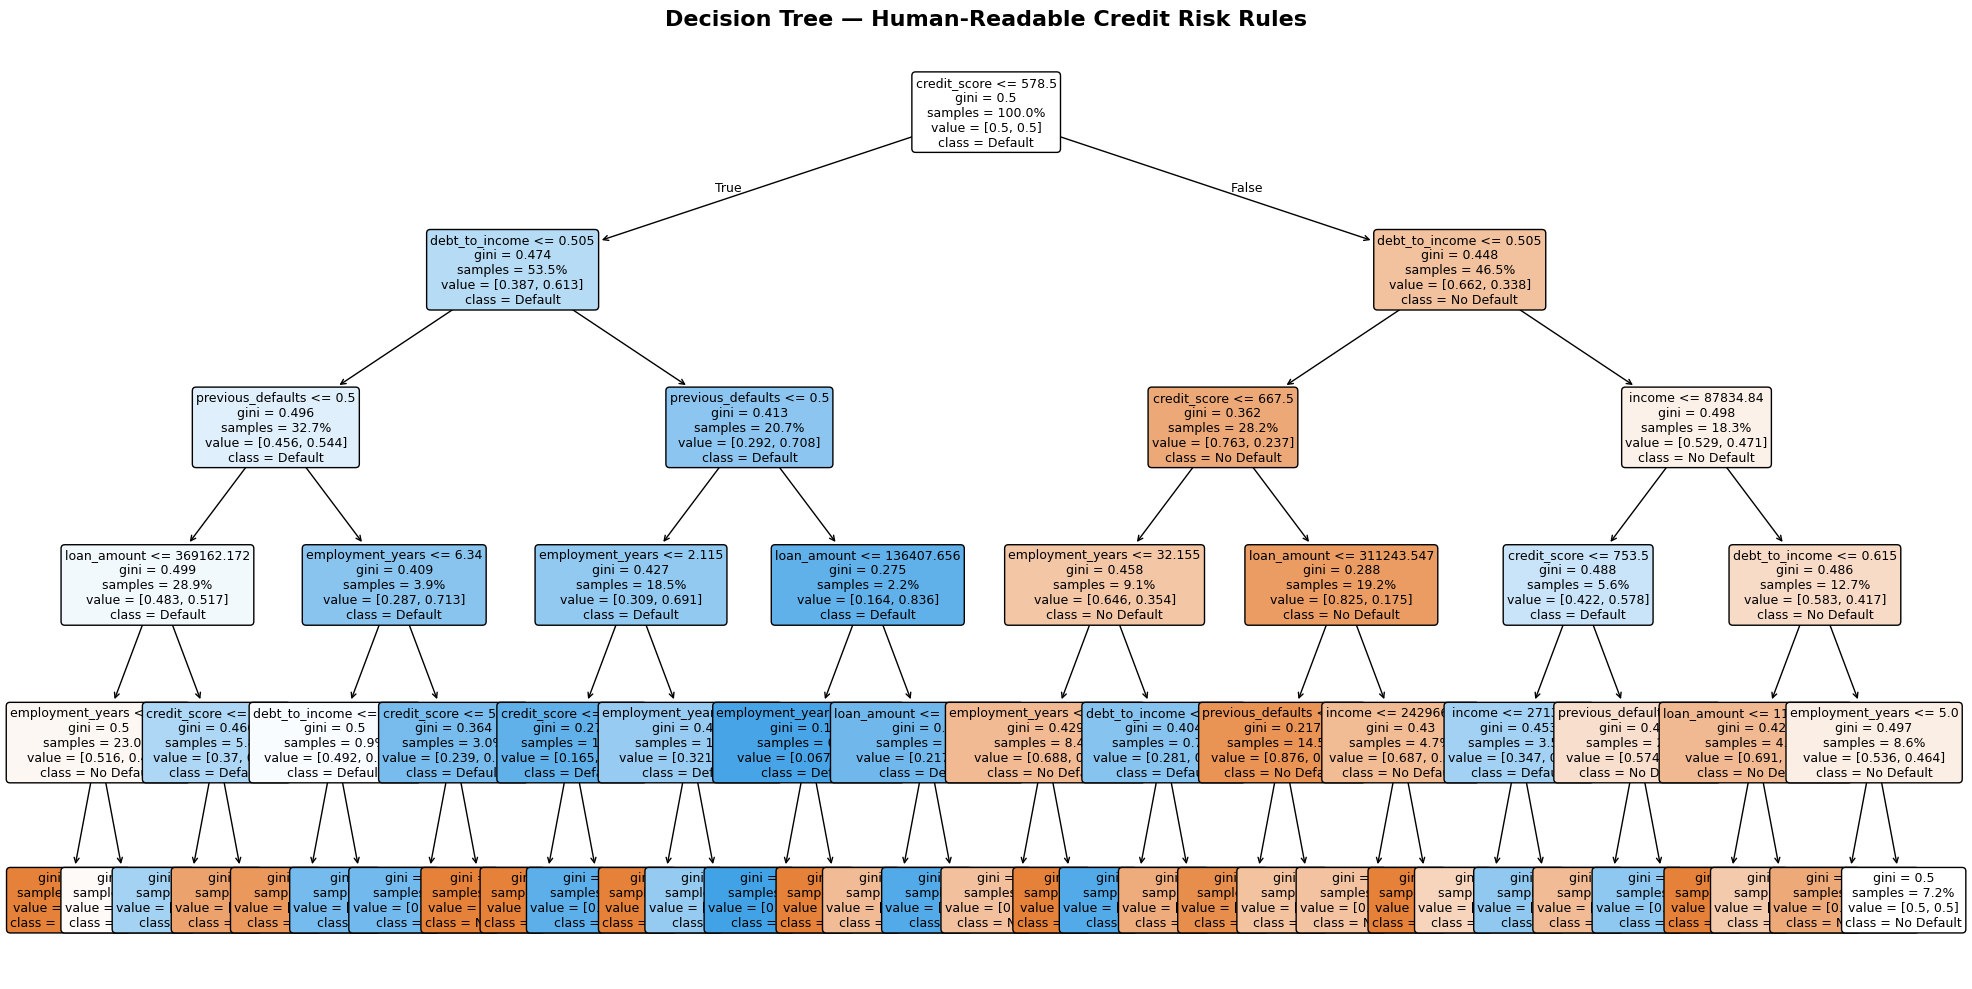

In [14]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(results['Decision Tree']['model'], feature_names=X.columns,
          class_names=['No Default', 'Default'], filled=True, rounded=True, ax=ax, fontsize=9, proportion=True)
ax.set_title('Decision Tree — Human-Readable Credit Risk Rules', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance — Which factors drive loan defaults?

Feature importance tells us **how much each variable contributes** to the model's predictions. This is critical in banking — regulators require **explainable** models.

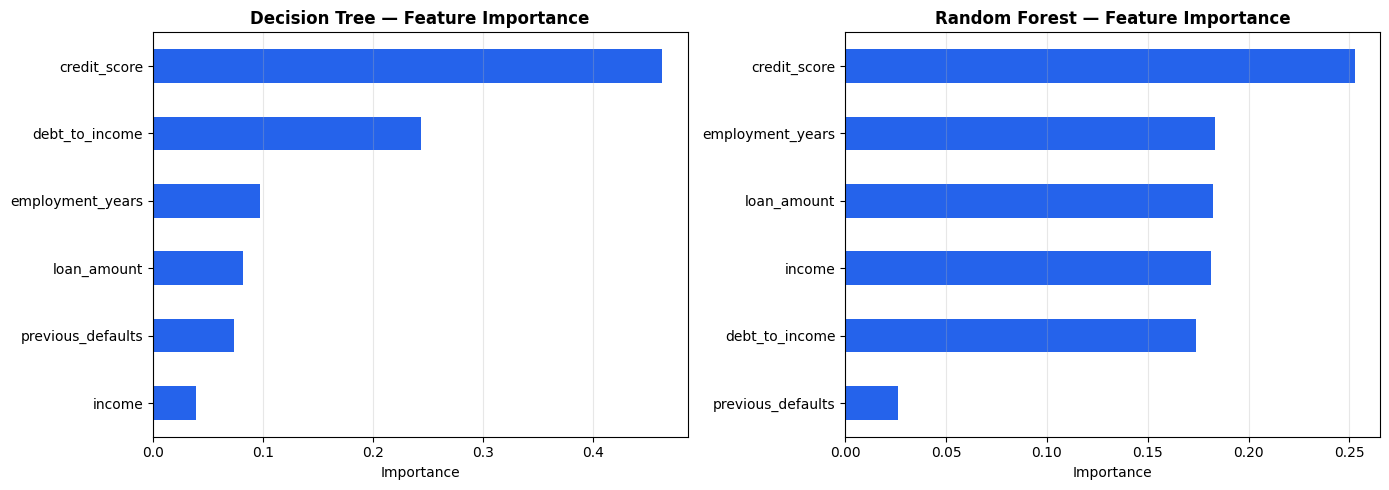

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ['Decision Tree', 'Random Forest']):
    model = results[name]['model']
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importances.plot(kind='barh', ax=ax, color='#2563EB')
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Business Cost Matrix & ROC Threshold Optimization

### Why a Cost Matrix?

In loan lending, **not all errors are equal**:

| Error Type | What It Means | Real Cost |
|------------|--------------|-----------|
| **False Negative** (FN) | Model says "safe" but borrower **defaults** | **$50,000** — the bank loses the loan amount |
| **False Positive** (FP) | Model says "risky" but borrower was **good** | **$5,000** — lost profit from rejecting a good customer |

Missing a default is **10x more expensive** than rejecting a good borrower. Standard accuracy treats both errors equally — we need a cost-aware approach.

**What happens if we ignore costs?** The model optimizes for accuracy, catching the easy cases but potentially missing expensive defaults.

In [16]:
COST_FN = 50000; COST_FP = 5000
print(f"Cost of missed default (FN): ${COST_FN:,}")
print(f"Cost of rejecting good borrower (FP): ${COST_FP:,}")
print(f"FN/FP cost ratio: {COST_FN/COST_FP:.0f}x — missing a default is 10x worse!")

for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    print(f"\n{name}: TP={tp} FP={fp} FN={fn} TN={tn} | Total Cost: ${total_cost:,.0f}")

Cost of missed default (FN): $50,000
Cost of rejecting good borrower (FP): $5,000
FN/FP cost ratio: 10x — missing a default is 10x worse!

Decision Tree: TP=142 FP=153 FN=159 TN=546 | Total Cost: $8,715,000

Random Forest: TP=75 FP=52 FN=226 TN=647 | Total Cost: $11,560,000

SGD Classifier: TP=237 FP=362 FN=64 TN=337 | Total Cost: $5,010,000


### Understanding Classification Metrics — Confusion Matrix, Precision, Recall, F1, ROC & AUC

Before we plot ROC curves, let's understand the **key metrics** used to evaluate classification models.

---

#### 1. Confusion Matrix

A confusion matrix shows the 4 possible outcomes of a binary classifier:

|  | **Predicted: No Default** | **Predicted: Default** |
|--|:---:|:---:|
| **Actual: No Default** | ✅ True Negative (TN) | ⚠️ False Positive (FP) |
| **Actual: Default** | ❌ False Negative (FN) | ✅ True Positive (TP) |

- **TN** — Correctly predicted "no default" → Good loan approved ✅
- **TP** — Correctly predicted "default" → Risky loan caught ✅
- **FP** — Predicted "default" but borrower was safe → Lost a good customer ⚠️
- **FN** — Predicted "no default" but borrower defaulted → **Bank loses money** ❌ (most expensive!)

---

#### 2. Precision, Recall & F1-Score

| Metric | Formula | In Plain English | Loan Example |
|--------|---------|-----------------|--------------|
| **Precision** | $\frac{TP}{TP + FP}$ | Of all loans we **flagged as risky**, how many actually defaulted? | High precision = fewer good customers wrongly rejected |
| **Recall (Sensitivity)** | $\frac{TP}{TP + FN}$ | Of all loans that **actually defaulted**, how many did we catch? | High recall = fewer defaults slipping through |
| **F1-Score** | $\frac{2 \times Precision \times Recall}{Precision + Recall}$ | Harmonic mean of precision and recall — balances both | High F1 = good at both catching defaults AND not over-rejecting |
| **Accuracy** | $\frac{TP + TN}{Total}$ | Overall correct predictions | ⚠️ Misleading with imbalanced data (95% accuracy ≠ good model!) |

**The Precision-Recall Trade-off:**
- **Raise the threshold** (e.g., 0.7) → Higher precision, lower recall (fewer flags, but more accurate flags)
- **Lower the threshold** (e.g., 0.3) → Higher recall, lower precision (catch more defaults, but more false alarms)
- For loans, **recall matters more** — missing a default (FN) costs 10× more than a false alarm (FP)

---

#### 3. ROC Curve (Receiver Operating Characteristic)

The ROC curve plots:
- **X-axis: False Positive Rate (FPR)** = $\frac{FP}{FP + TN}$ — how many good loans we wrongly reject
- **Y-axis: True Positive Rate (TPR / Recall)** = $\frac{TP}{TP + FN}$ — how many defaults we catch

Each point on the curve represents a **different threshold**. As we lower the threshold:
- We catch **more defaults** (TPR goes up ↑)
- But we also **wrongly reject more good loans** (FPR goes up →)

**How to read an ROC curve:**
- A curve **hugging the top-left corner** = excellent model (high TPR, low FPR)
- The **diagonal dashed line** = random guessing (50/50 coin flip)
- A curve **below the diagonal** = worse than random (something is wrong!)

---

#### 4. AUC (Area Under the ROC Curve)

AUC is a single number (0 to 1) summarizing the entire ROC curve:

| AUC Score | Interpretation |
|:---------:|---------------|
| **1.0** | Perfect classifier — catches every default with zero false alarms |
| **0.9 – 1.0** | Excellent — rare in practice |
| **0.8 – 0.9** | Good — typical for well-tuned models |
| **0.7 – 0.8** | Fair — room for improvement |
| **0.5** | Random guessing — model learned nothing |
| **< 0.5** | Worse than random — labels may be flipped |

**Business interpretation:** AUC = 0.85 means that if you randomly pick one defaulter and one non-defaulter, the model ranks the defaulter as riskier **85% of the time**.

---

#### 5. Why ROC-AUC over Accuracy?

| Metric | Imbalanced Data (5% defaults) | Balanced Data (50/50) |
|--------|-------------------------------|----------------------|
| **Accuracy** | ❌ Misleading — "always predict no default" gets 95% | ✅ Works fine |
| **ROC-AUC** | ✅ Still meaningful — measures ranking quality regardless of class ratio | ✅ Works fine |

**Bottom line:** For loan approval (and any imbalanced problem), **always use ROC-AUC, Precision, Recall, and F1** instead of plain accuracy.

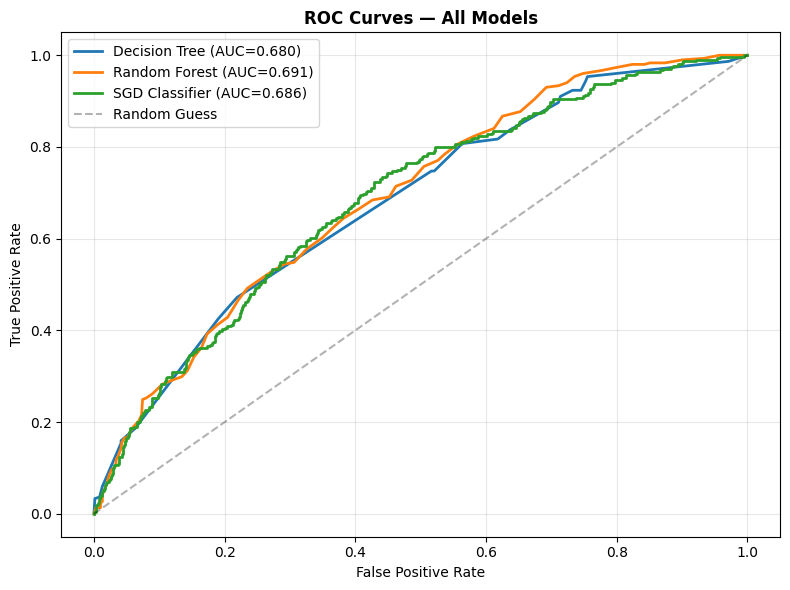

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Guess')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Optimization — Find the Cheapest Operating Point

By default, models use threshold=0.5 (if probability > 50%, predict default). But since FN costs 10x more than FP, we should **lower the threshold** to catch more defaults, even at the cost of some false alarms.

**What happens if we skip threshold optimization?** We use the default 0.5 threshold, potentially missing many expensive defaults.

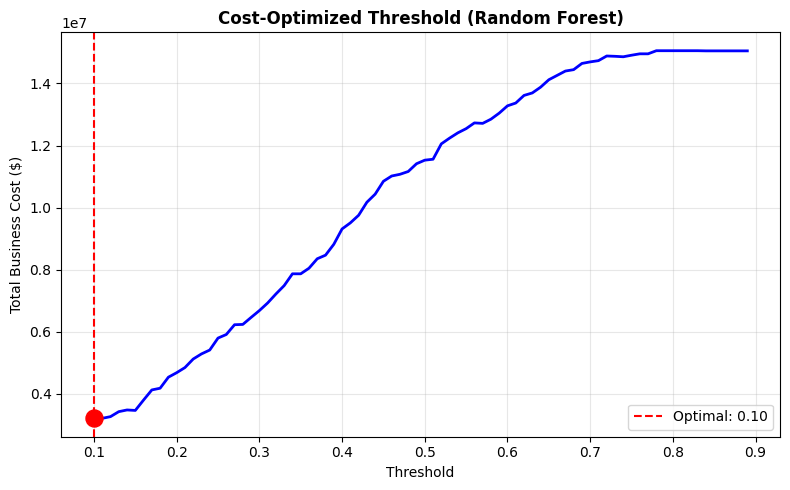


✅ Optimal threshold: 0.10 | Min cost: $3,215,000


In [18]:
rf_prob = results['Random Forest']['y_prob']
thresholds_range = np.arange(0.1, 0.9, 0.01)
total_costs = []
for thresh in thresholds_range:
    y_pred_thresh = (rf_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    total_costs.append(fn * COST_FN + fp * COST_FP)

optimal_idx = np.argmin(total_costs)
optimal_threshold = thresholds_range[optimal_idx]
min_cost = total_costs[optimal_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds_range, total_costs, 'b-', linewidth=2)
ax.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
ax.scatter([optimal_threshold], [min_cost], color='red', s=150, zorder=5)
ax.set_xlabel('Threshold'); ax.set_ylabel('Total Business Cost ($)')
ax.set_title('Cost-Optimized Threshold (Random Forest)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Optimal threshold: {optimal_threshold:.2f} | Min cost: ${min_cost:,.0f}")

## Step 7: Strategic Analysis — Board-Ready Recommendation

Now we apply the **optimal threshold** and build a business case that a bank's risk committee can act on.

In [19]:
y_pred_optimal = (rf_prob >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm_optimal.ravel()

print("=" * 70)
print("MODEL DEPLOYMENT RECOMMENDATION — Bank Risk Committee")
print("=" * 70)
print(f"\n1. RECOMMENDED MODEL: Random Forest (threshold={optimal_threshold:.2f})")
print(f"   Recall: {tp/(tp+fn):.2%} | Precision: {tp/(tp+fp):.2%}")
print(f"   ROC-AUC: {results['Random Forest']['roc_auc']:.4f}")

MODEL DEPLOYMENT RECOMMENDATION — Bank Risk Committee

1. RECOMMENDED MODEL: Random Forest (threshold=0.10)
   Recall: 96.68% | Precision: 34.89%
   ROC-AUC: 0.6913


### Financial Impact & Top Risk Factors

In [20]:
annual_loans = 50000
default_rate = y_test.mean()
total_defaults = annual_loans * default_rate
print(f"2. FINANCIAL IMPACT (at {annual_loans:,} annual loans):")
print(f"   Expected defaults: {total_defaults:,.0f}")
print(f"   Value of 1% recall improvement: ${total_defaults * 0.01 * COST_FN:,.0f}/year")

print(f"\n3. TOP RISK FACTORS:")
rf_importance = pd.Series(results['Random Forest']['model'].feature_importances_, index=X.columns).sort_values(ascending=False)
for feat, imp in rf_importance.head(3).items():
    print(f"   {feat}: {imp:.3f}")

2. FINANCIAL IMPACT (at 50,000 annual loans):
   Expected defaults: 15,050
   Value of 1% recall improvement: $7,525,000/year

3. TOP RISK FACTORS:
   credit_score: 0.253
   employment_years: 0.184
   loan_amount: 0.182
